# 🎮 Dota 2 Match Data Exploration

This notebook explores the match data we've collected for training the outcome prediction model.

> **Prerequisites:** Run the following before executing this notebook:
> ```bash
> python scripts/fetch_data.py --count 500   # collect match data
> python scripts/process_data.py --db --enhanced-features  # process into numpy arrays
> ```

**Contents:**
1. Data Loading & Overview
2. Match Duration Analysis
3. Time-Series Feature Visualization
4. Gold & XP Advantage Evolution
5. Hero Analysis
6. Win Condition Analysis
7. Feature Statistics


In [16]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add src to path
sys.path.insert(0, "../src")

from dota_predictor.data.match import Match

# Style settings
plt.style.use('dark_background')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Colors for teams
RADIANT_COLOR = '#4ade80'  # Green
DIRE_COLOR = '#f87171'     # Red

print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Data Loading & Overview


In [17]:
# Load raw matches
RAW_PATH = Path("../data/raw/matches.json")
PROCESSED_PATH = Path("../data/processed")

with open(RAW_PATH) as f:
    raw_matches = json.load(f)

# Convert to Match objects
matches = [Match.from_api_response(m) for m in raw_matches]

print(f"📊 Loaded {len(matches)} matches")
print(f"   File size: {RAW_PATH.stat().st_size / 1024 / 1024:.2f} MB")


📊 Loaded 200 matches
   File size: 53.38 MB


In [18]:
# Load processed data
train_features = np.load(PROCESSED_PATH / "train_features.npy")
train_labels = np.load(PROCESSED_PATH / "train_labels.npy")
train_heroes = np.load(PROCESSED_PATH / "train_heroes.npy")
train_masks = np.load(PROCESSED_PATH / "train_masks.npy")
train_durations = np.load(PROCESSED_PATH / "train_durations.npy")

val_features = np.load(PROCESSED_PATH / "val_features.npy")
val_labels = np.load(PROCESSED_PATH / "val_labels.npy")

norm_stats = np.load(PROCESSED_PATH / "normalization.npz")

with open(PROCESSED_PATH / "metadata.json") as f:
    metadata = json.load(f)

print("📦 Processed Data Shapes:")
print(f"   train_features: {train_features.shape} (matches, minutes, features)")
print(f"   train_labels:   {train_labels.shape}")
print(f"   train_heroes:   {train_heroes.shape} (matches, 10 heroes)")
print(f"   val_features:   {val_features.shape}")
print(f"\n📝 Feature names: {metadata['feature_names']}")


📦 Processed Data Shapes:
   train_features: (39812, 60, 20) (matches, minutes, features)
   train_labels:   (39812,)
   train_heroes:   (39812, 10) (matches, 10 heroes)
   val_features:   (9952, 60, 20)

📝 Feature names: ['radiant_gold', 'radiant_xp', 'dire_gold', 'dire_xp', 'gold_diff', 'xp_diff', 'radiant_lh', 'dire_lh']


In [19]:
# Create summary dataframe
summary_data = []
for m in matches:
    summary_data.append({
        'match_id': m.match_id,
        'duration_min': m.duration_minutes,
        'radiant_win': m.radiant_win,
        'radiant_score': m.radiant_score,
        'dire_score': m.dire_score,
        'total_kills': m.radiant_score + m.dire_score,
        'has_time_series': m.has_time_series,
    })

df = pd.DataFrame(summary_data)
df.head(10)


,match_id,duration_min,radiant_win,radiant_score,dire_score,total_kills,has_time_series
0,8610570203,26,False,19,51,70,True
1,8610532052,29,False,28,32,60,True
2,8610529607,28,True,44,10,54,True
3,8610508424,30,True,41,14,55,True
4,8610504907,26,True,48,9,57,True
5,8610467954,30,False,26,34,60,True
6,8610422123,28,False,12,28,40,True
7,8610421089,26,True,33,15,48,True
8,8610407872,44,True,38,21,59,True
9,8610399089,31,False,11,81,92,True


In [20]:
# Basic statistics
print("📈 Dataset Statistics")
print("=" * 40)
print(f"Total matches:      {len(df)}")
print(f"Radiant wins:       {df['radiant_win'].sum()} ({df['radiant_win'].mean():.1%})")
print(f"Dire wins:          {(~df['radiant_win']).sum()} ({(~df['radiant_win']).mean():.1%})")
print(f"\nDuration (minutes):")
print(f"  Min:    {df['duration_min'].min()}")
print(f"  Max:    {df['duration_min'].max()}")
print(f"  Mean:   {df['duration_min'].mean():.1f}")
print(f"  Median: {df['duration_min'].median():.1f}")
print(f"\nKills per match:")
print(f"  Mean:   {df['total_kills'].mean():.1f}")
print(f"  Median: {df['total_kills'].median():.1f}")


📈 Dataset Statistics
Total matches:      200
Radiant wins:       108 (54.0%)
Dire wins:          92 (46.0%)

Duration (minutes):
  Min:    18
  Max:    74
  Mean:   32.3
  Median: 30.0

Kills per match:
  Mean:   58.5
  Median: 56.5


## 2. Match Duration Analysis


/var/folders/s8/b56jfb092vb7ddc2klr5tlqh0000gn/T/ipykernel_57200/930525029.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_by_duration = df.groupby('duration_bucket')['radiant_win'].agg(['mean', 'count'])


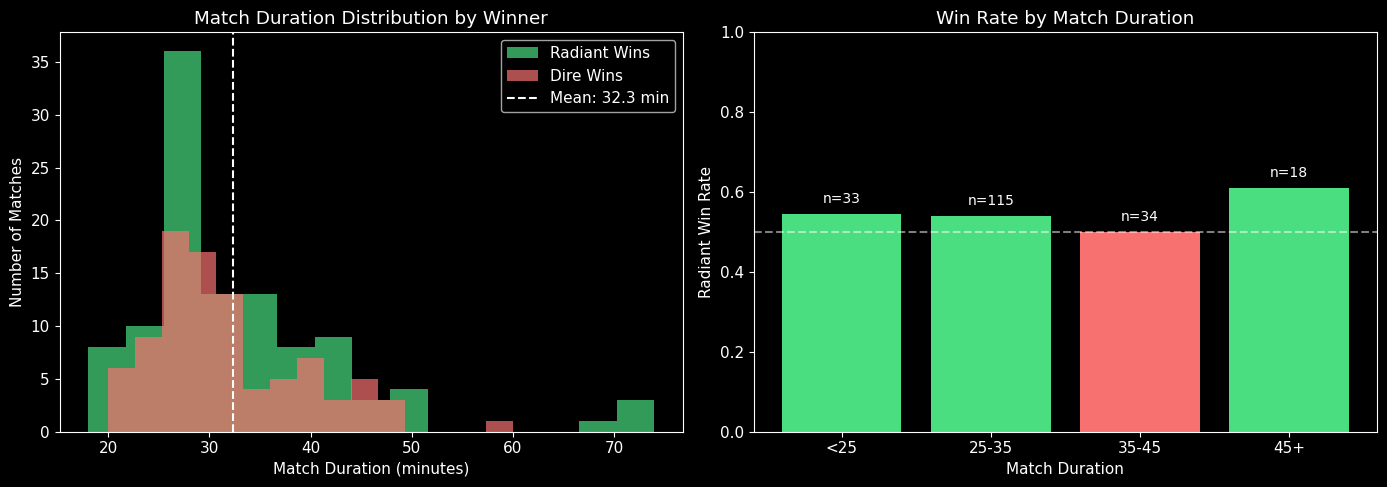

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram
ax1 = axes[0]
radiant_durations = df[df['radiant_win']]['duration_min']
dire_durations = df[~df['radiant_win']]['duration_min']

ax1.hist(radiant_durations, bins=15, alpha=0.7, label='Radiant Wins', color=RADIANT_COLOR)
ax1.hist(dire_durations, bins=15, alpha=0.7, label='Dire Wins', color=DIRE_COLOR)
ax1.axvline(df['duration_min'].mean(), color='white', linestyle='--', label=f'Mean: {df["duration_min"].mean():.1f} min')
ax1.set_xlabel('Match Duration (minutes)')
ax1.set_ylabel('Number of Matches')
ax1.set_title('Match Duration Distribution by Winner')
ax1.legend()

# Win rate by duration bucket
ax2 = axes[1]
df['duration_bucket'] = pd.cut(df['duration_min'], bins=[0, 25, 35, 45, 100], labels=['<25', '25-35', '35-45', '45+'])
win_by_duration = df.groupby('duration_bucket')['radiant_win'].agg(['mean', 'count'])

bars = ax2.bar(win_by_duration.index.astype(str), win_by_duration['mean'], 
               color=[RADIANT_COLOR if x > 0.5 else DIRE_COLOR for x in win_by_duration['mean']])
ax2.axhline(0.5, color='white', linestyle='--', alpha=0.5)
ax2.set_xlabel('Match Duration')
ax2.set_ylabel('Radiant Win Rate')
ax2.set_title('Win Rate by Match Duration')
ax2.set_ylim(0, 1)

# Add count labels
for bar, count in zip(bars, win_by_duration['count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'n={int(count)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 3. Time-Series Feature Visualization


In [22]:
# Pick a sample match to visualize
sample_match = matches[0]
print(f"📋 Sample Match: {sample_match.match_id}")
print(f"   Duration: {sample_match.duration_minutes} minutes")
print(f"   Winner: {'Radiant' if sample_match.radiant_win else 'Dire'}")
print(f"   Score: {sample_match.radiant_score} - {sample_match.dire_score}")


📋 Sample Match: 8610570203
   Duration: 26 minutes
   Winner: Dire
   Score: 19 - 51


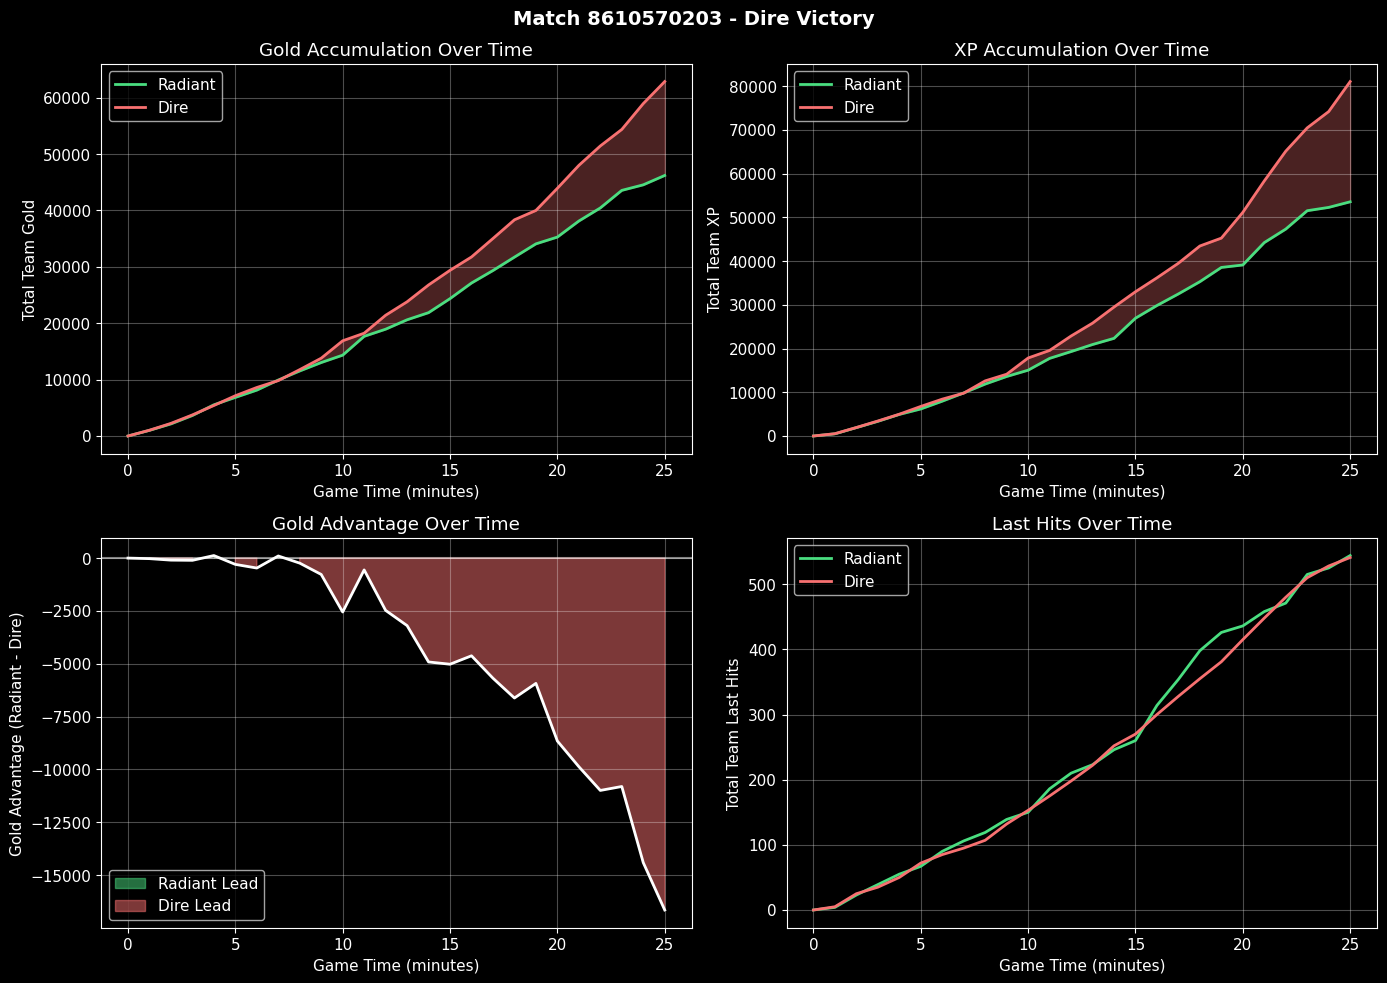

In [23]:
# Extract time-series for sample match
features = sample_match.get_full_time_series(max_minutes=60)
duration = sample_match.duration_minutes

# Feature indices
RADIANT_GOLD, RADIANT_XP = 0, 1
DIRE_GOLD, DIRE_XP = 2, 3
GOLD_DIFF, XP_DIFF = 4, 5
RADIANT_LH, DIRE_LH = 6, 7

minutes = np.arange(duration)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gold over time
ax1 = axes[0, 0]
ax1.plot(minutes, features[:duration, RADIANT_GOLD], color=RADIANT_COLOR, linewidth=2, label='Radiant')
ax1.plot(minutes, features[:duration, DIRE_GOLD], color=DIRE_COLOR, linewidth=2, label='Dire')
ax1.fill_between(minutes, features[:duration, RADIANT_GOLD], features[:duration, DIRE_GOLD], 
                 alpha=0.3, color=RADIANT_COLOR if sample_match.radiant_win else DIRE_COLOR)
ax1.set_xlabel('Game Time (minutes)')
ax1.set_ylabel('Total Team Gold')
ax1.set_title('Gold Accumulation Over Time')
ax1.legend()
ax1.grid(alpha=0.3)

# XP over time
ax2 = axes[0, 1]
ax2.plot(minutes, features[:duration, RADIANT_XP], color=RADIANT_COLOR, linewidth=2, label='Radiant')
ax2.plot(minutes, features[:duration, DIRE_XP], color=DIRE_COLOR, linewidth=2, label='Dire')
ax2.fill_between(minutes, features[:duration, RADIANT_XP], features[:duration, DIRE_XP], 
                 alpha=0.3, color=RADIANT_COLOR if sample_match.radiant_win else DIRE_COLOR)
ax2.set_xlabel('Game Time (minutes)')
ax2.set_ylabel('Total Team XP')
ax2.set_title('XP Accumulation Over Time')
ax2.legend()
ax2.grid(alpha=0.3)

# Gold advantage
ax3 = axes[1, 0]
gold_diff = features[:duration, GOLD_DIFF]
ax3.plot(minutes, gold_diff, color='white', linewidth=2)
ax3.fill_between(minutes, 0, gold_diff, where=(gold_diff >= 0), color=RADIANT_COLOR, alpha=0.5, label='Radiant Lead')
ax3.fill_between(minutes, 0, gold_diff, where=(gold_diff < 0), color=DIRE_COLOR, alpha=0.5, label='Dire Lead')
ax3.axhline(0, color='white', linestyle='-', alpha=0.5)
ax3.set_xlabel('Game Time (minutes)')
ax3.set_ylabel('Gold Advantage (Radiant - Dire)')
ax3.set_title('Gold Advantage Over Time')
ax3.legend()
ax3.grid(alpha=0.3)

# Last hits
ax4 = axes[1, 1]
ax4.plot(minutes, features[:duration, RADIANT_LH], color=RADIANT_COLOR, linewidth=2, label='Radiant')
ax4.plot(minutes, features[:duration, DIRE_LH], color=DIRE_COLOR, linewidth=2, label='Dire')
ax4.set_xlabel('Game Time (minutes)')
ax4.set_ylabel('Total Team Last Hits')
ax4.set_title('Last Hits Over Time')
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle(f'Match {sample_match.match_id} - {"Radiant" if sample_match.radiant_win else "Dire"} Victory', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Gold & XP Advantage Evolution


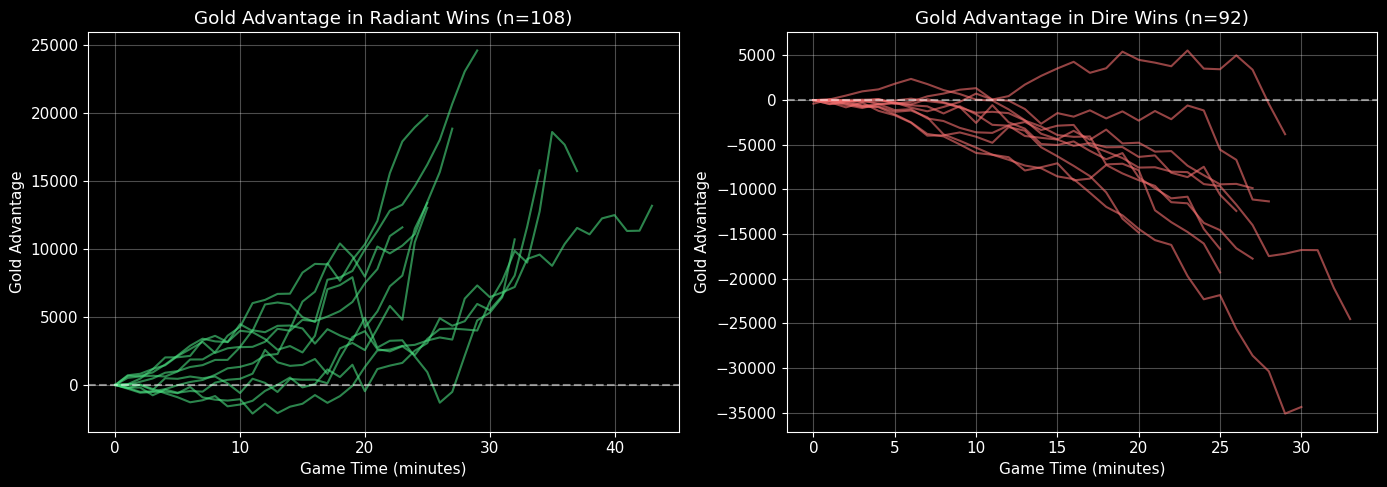

In [24]:
# Plot gold advantage for multiple matches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate by winner
radiant_wins = [m for m in matches if m.radiant_win and m.has_time_series]
dire_wins = [m for m in matches if not m.radiant_win and m.has_time_series]

# Gold advantage for Radiant wins
ax1 = axes[0]
for m in radiant_wins[:10]:  # Limit to 10 for readability
    features = m.get_full_time_series()
    duration = m.duration_minutes
    ax1.plot(range(duration), features[:duration, GOLD_DIFF], alpha=0.6, color=RADIANT_COLOR)

ax1.axhline(0, color='white', linestyle='--', alpha=0.5)
ax1.set_xlabel('Game Time (minutes)')
ax1.set_ylabel('Gold Advantage')
ax1.set_title(f'Gold Advantage in Radiant Wins (n={len(radiant_wins)})')
ax1.grid(alpha=0.3)

# Gold advantage for Dire wins
ax2 = axes[1]
for m in dire_wins[:10]:
    features = m.get_full_time_series()
    duration = m.duration_minutes
    ax2.plot(range(duration), features[:duration, GOLD_DIFF], alpha=0.6, color=DIRE_COLOR)

ax2.axhline(0, color='white', linestyle='--', alpha=0.5)
ax2.set_xlabel('Game Time (minutes)')
ax2.set_ylabel('Gold Advantage')
ax2.set_title(f'Gold Advantage in Dire Wins (n={len(dire_wins)})')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


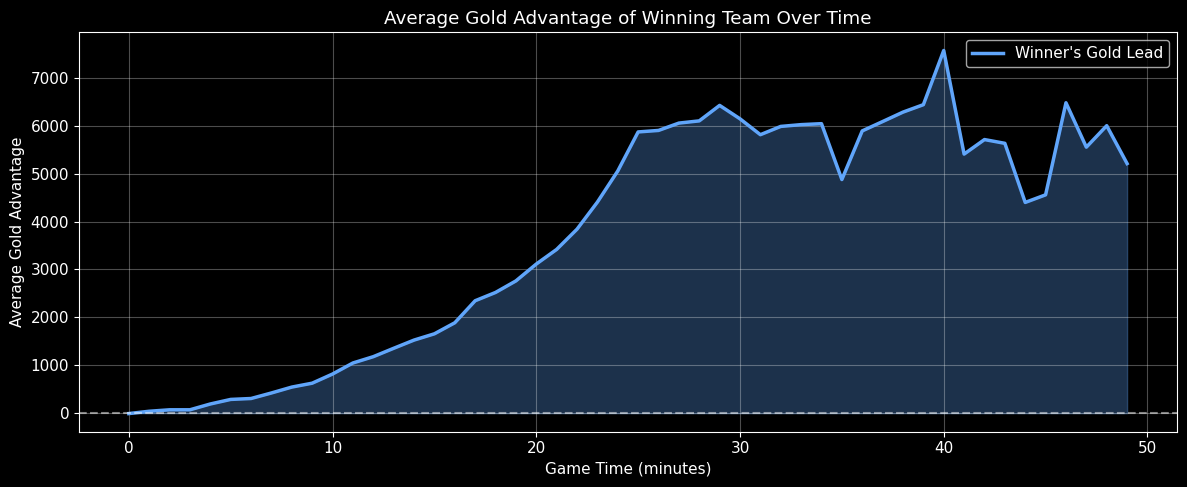

💡 Key Insight: Winning team has ~1656 gold lead at 15 min, ~5870 at 25 min


In [25]:
# Average gold advantage by minute for winners
max_min = 50
winner_gold_avg = np.zeros(max_min)
winner_counts = np.zeros(max_min)

for m in matches:
    if not m.has_time_series:
        continue
    features = m.get_full_time_series()
    duration = min(m.duration_minutes, max_min)
    
    # Gold diff from Radiant perspective - flip if Dire won
    gold_diff = features[:duration, GOLD_DIFF]
    if not m.radiant_win:
        gold_diff = -gold_diff  # Flip to winner's perspective
    
    winner_gold_avg[:duration] += gold_diff
    winner_counts[:duration] += 1

# Normalize
winner_gold_avg = np.divide(winner_gold_avg, winner_counts, where=winner_counts > 0)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

minutes = np.arange(max_min)
ax.plot(minutes, winner_gold_avg, color='#60a5fa', linewidth=2.5, label="Winner's Gold Lead")
ax.fill_between(minutes, 0, winner_gold_avg, alpha=0.3, color='#60a5fa')
ax.axhline(0, color='white', linestyle='--', alpha=0.5)

ax.set_xlabel('Game Time (minutes)')
ax.set_ylabel('Average Gold Advantage')
ax.set_title("Average Gold Advantage of Winning Team Over Time")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"💡 Key Insight: Winning team has ~{winner_gold_avg[15]:.0f} gold lead at 15 min, ~{winner_gold_avg[25]:.0f} at 25 min")


## 5. Hero Analysis


In [26]:
# Import complete hero mapping (127 heroes)
from dota_predictor.data import HERO_NAMES, get_hero_name

print(f"Loaded {len(HERO_NAMES)} hero names")

# Count hero picks and wins
hero_stats = {}

for m in matches:
    radiant_won = m.radiant_win
    
    for p in m.radiant_players:
        hero_id = p.hero_id
        if hero_id not in hero_stats:
            hero_stats[hero_id] = {'picks': 0, 'wins': 0}
        hero_stats[hero_id]['picks'] += 1
        if radiant_won:
            hero_stats[hero_id]['wins'] += 1
    
    for p in m.dire_players:
        hero_id = p.hero_id
        if hero_id not in hero_stats:
            hero_stats[hero_id] = {'picks': 0, 'wins': 0}
        hero_stats[hero_id]['picks'] += 1
        if not radiant_won:
            hero_stats[hero_id]['wins'] += 1

# Create dataframe
hero_df = pd.DataFrame([
    {
        'hero_id': hid,
        'hero_name': get_hero_name(hid),
        'picks': stats['picks'],
        'wins': stats['wins'],
        'win_rate': stats['wins'] / stats['picks'] if stats['picks'] > 0 else 0
    }
    for hid, stats in hero_stats.items()
]).sort_values('picks', ascending=False)

print(f"🦸 Unique heroes picked: {len(hero_df)}")
hero_df.head(15)


Loaded 127 hero names
🦸 Unique heroes picked: 124


,hero_id,hero_name,picks,wins,win_rate
5,87,Disruptor,53,27,0.509434
54,49,Dragon Knight,50,23,0.460000
20,14,Pudge,47,25,0.531915
3,84,Ogre Magi,46,21,0.456522
6,128,Snapfire,45,24,0.533333
38,8,Juggernaut,41,21,0.512195
26,79,Shadow Demon,39,21,0.538462
30,2,Axe,37,15,0.405405
2,21,Windranger,37,18,0.486486
37,70,Ursa,37,22,0.594595


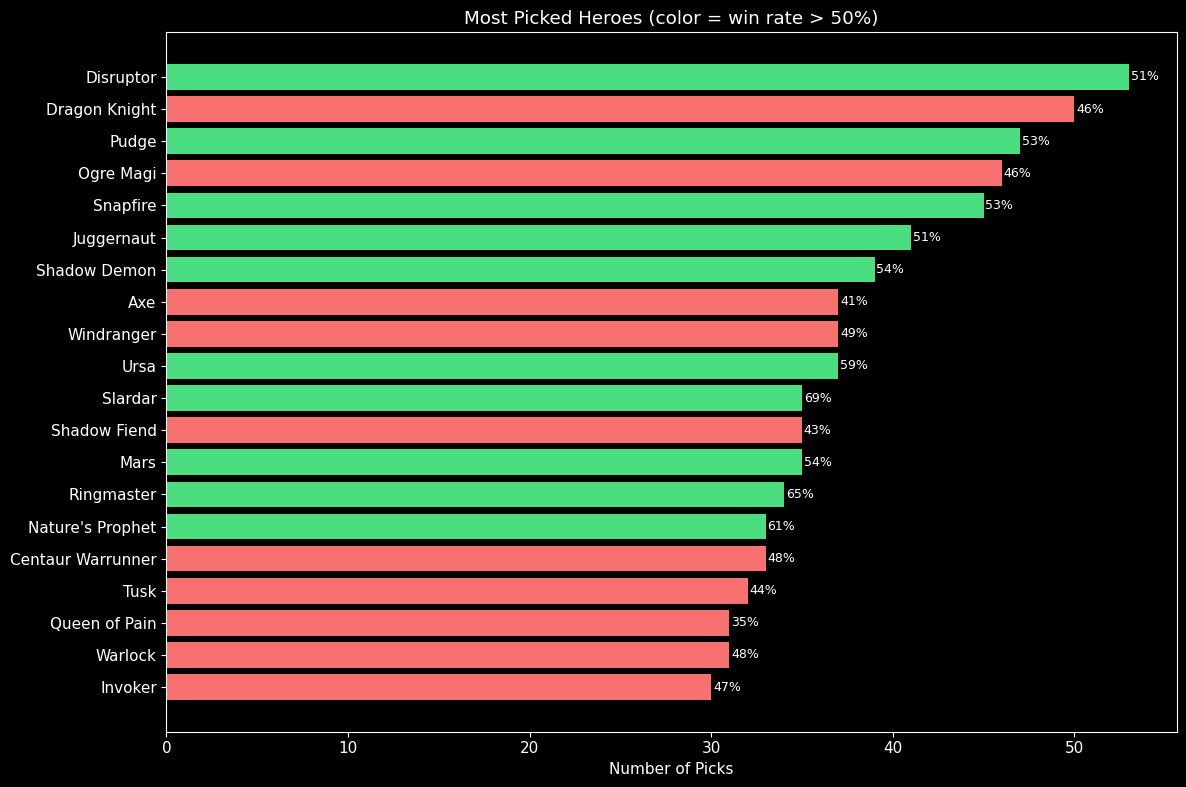

In [27]:
# Visualize hero picks
fig, ax = plt.subplots(figsize=(12, 8))

# Most picked heroes
top_picked = hero_df.head(20)
colors = [RADIANT_COLOR if wr > 0.5 else DIRE_COLOR for wr in top_picked['win_rate']]
bars = ax.barh(top_picked['hero_name'], top_picked['picks'], color=colors)
ax.set_xlabel('Number of Picks')
ax.set_title('Most Picked Heroes (color = win rate > 50%)')
ax.invert_yaxis()

# Add win rate labels
for bar, wr in zip(bars, top_picked['win_rate']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{wr:.0%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 6. Win Condition Analysis


/var/folders/s8/b56jfb092vb7ddc2klr5tlqh0000gn/T/ipykernel_57200/474676488.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gold_leader_wins = analysis_df.groupby('minute').apply(


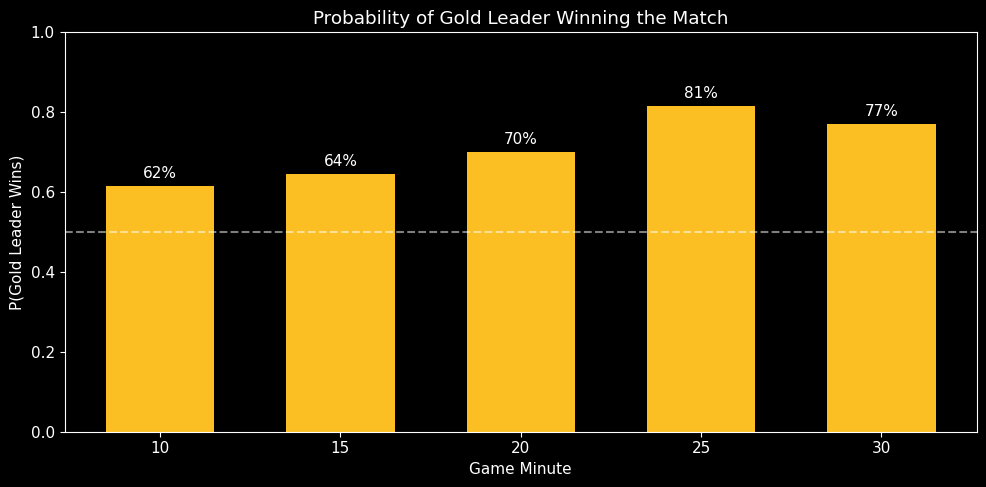

💡 Insight: The correlation between leading and winning increases over time.
   This is what our LSTM model needs to learn!


In [28]:
# Analyze gold/xp lead correlation with winning at different times
time_points = [10, 15, 20, 25, 30]
analysis_data = []

for m in matches:
    if not m.has_time_series:
        continue
    
    features = m.get_full_time_series()
    duration = m.duration_minutes
    
    for t in time_points:
        if t < duration:
            gold_diff = features[t, GOLD_DIFF]
            xp_diff = features[t, XP_DIFF]
            
            analysis_data.append({
                'match_id': m.match_id,
                'minute': t,
                'gold_diff': gold_diff,
                'xp_diff': xp_diff,
                'radiant_win': m.radiant_win,
                'radiant_leading_gold': gold_diff > 0,
            })

analysis_df = pd.DataFrame(analysis_data)

# Win rate when leading at different time points
fig, ax = plt.subplots(figsize=(10, 5))

gold_leader_wins = analysis_df.groupby('minute').apply(
    lambda x: (x['radiant_leading_gold'] == x['radiant_win']).mean()
)
ax.bar(gold_leader_wins.index, gold_leader_wins.values, color='#fbbf24', width=3)
ax.axhline(0.5, color='white', linestyle='--', alpha=0.5)
ax.set_xlabel('Game Minute')
ax.set_ylabel('P(Gold Leader Wins)')
ax.set_title('Probability of Gold Leader Winning the Match')
ax.set_ylim(0, 1)

for x, y in zip(gold_leader_wins.index, gold_leader_wins.values):
    ax.text(x, y + 0.02, f'{y:.0%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("💡 Insight: The correlation between leading and winning increases over time.")
print("   This is what our LSTM model needs to learn!")


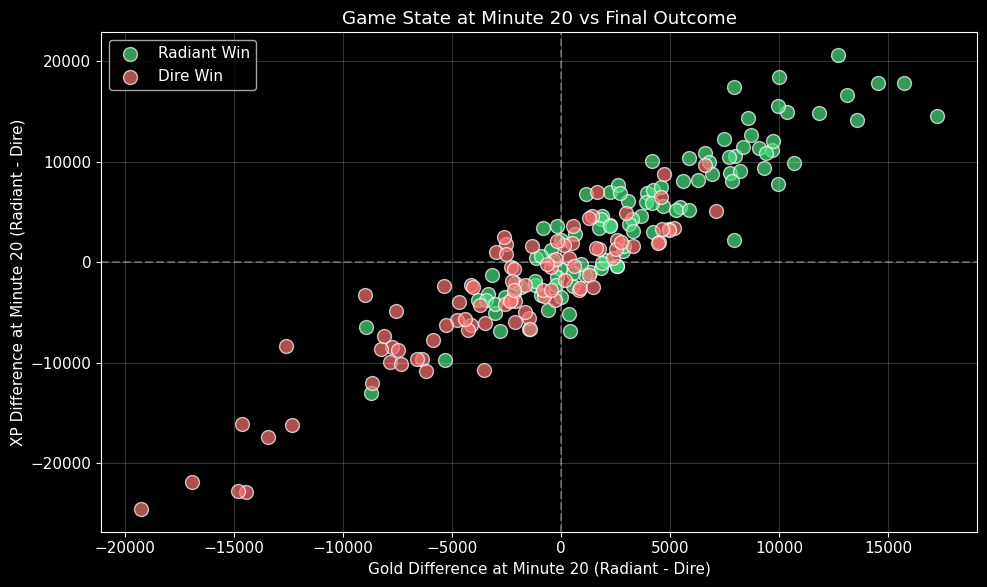

💡 This scatter plot shows the 'separability' of our features.
   A good model should be able to draw a decision boundary here.


In [29]:
# Scatter plot: Gold diff vs XP diff at minute 20, colored by outcome
fig, ax = plt.subplots(figsize=(10, 6))

minute_20 = analysis_df[analysis_df['minute'] == 20].copy()

radiant_wins = minute_20[minute_20['radiant_win']]
dire_wins = minute_20[~minute_20['radiant_win']]

ax.scatter(radiant_wins['gold_diff'], radiant_wins['xp_diff'], 
           c=RADIANT_COLOR, alpha=0.7, s=100, label='Radiant Win', edgecolors='white')
ax.scatter(dire_wins['gold_diff'], dire_wins['xp_diff'], 
           c=DIRE_COLOR, alpha=0.7, s=100, label='Dire Win', edgecolors='white')

ax.axhline(0, color='white', linestyle='--', alpha=0.3)
ax.axvline(0, color='white', linestyle='--', alpha=0.3)

ax.set_xlabel('Gold Difference at Minute 20 (Radiant - Dire)')
ax.set_ylabel('XP Difference at Minute 20 (Radiant - Dire)')
ax.set_title('Game State at Minute 20 vs Final Outcome')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("💡 This scatter plot shows the 'separability' of our features.")
print("   A good model should be able to draw a decision boundary here.")


## 7. Feature Statistics


In [30]:
# Show feature statistics
# Reconstruct feature names from known lists to handle stale metadata
BASIC_FEATURES = ["radiant_gold", "radiant_xp", "dire_gold", "dire_xp",
                  "gold_diff", "xp_diff", "radiant_lh", "dire_lh"]
ENHANCED_EXTRAS = ["radiant_kills", "dire_kills", "kill_diff",
                   "radiant_towers", "dire_towers", "tower_diff",
                   "radiant_barracks", "dire_barracks", "barracks_diff",
                   "radiant_roshan", "dire_roshan", "roshan_diff"]
ALL_FEATURES = BASIC_FEATURES + ENHANCED_EXTRAS

mean = norm_stats['mean']
std = norm_stats['std']
feature_names = ALL_FEATURES[:len(mean)]  # match length of normalization array

norm_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean': mean,
    'Std': std,
})

print("📊 Feature Statistics (raw values — model trains on unnormalized features)")
print("")
norm_df


📊 Feature Statistics (raw values — model trains on unnormalized features)



,Feature,Mean,Std
0,radiant_gold,19340.718750,28292.935547
1,radiant_xp,23238.849609,36338.253906
2,dire_gold,19371.080078,28482.228516
3,dire_xp,23282.310547,36588.093750
4,gold_diff,-30.543724,4964.139648
5,xp_diff,-44.403366,7197.044434
6,radiant_lh,232.724182,340.239014
7,dire_lh,233.101440,343.162445
8,radiant_kills,19.581255,13.802963
9,dire_kills,19.213638,13.895148


## Summary

### Key Findings

1. **Gold/XP leads are predictive** — Teams leading at minute 20+ have significantly higher win rates
2. **Time-series evolution matters** — The trajectory of advantages tells a richer story than any single snapshot
3. **Feature separability** — Gold and XP differences form a clear decision boundary, which the LSTM learns to track over time
